In [2]:
%pip install torch torchvision torchaudio

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   - -------------------------------------- 5.2/123.0 MB 29.0 MB/s eta 0:00:05
   ---- ----------------------------------- 14.2/123.0 MB 37.0 MB/s eta 0:00:03
   ------- -------------------------------- 23.3/123.0 MB 38.8 MB/s eta 0:00:03
   ---------- ----------------------------- 32.0/123.0 MB 39.8 MB/s eta 0:00:03
   ------------- -------------------------- 40.9/123.0 MB 40.0 MB/s eta 0:00:03
   ---------------- ----------------------- 49.3/123.0 MB 39.7 MB/s eta 0:00:02
   ------------------ --------------------- 57.4/123.0 MB 39.8 MB/s eta 0:00:02
   --------------------- ------------------ 65.3/123.0 MB 39.6 MB/s eta 0:00:02
   ----------------------- ---------------- 73.1/123.0 MB 39.5 MB/s eta 0:00:02
   -------------------------- ------------- 81.5/123.0 MB 39.4 MB/s eta 0:00:02
   ----------------------------- ---------- 89.4/123.0 MB 39.4 MB/s 

In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils as utils
from torch.utils.data import DataLoader
from torch.utils.data import random_split
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [40]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
training_data = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testing_data = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Split the full training set into 90% Train and 10% Validation Sets
train_size = int(0.9 * len(training_data))
val_size = len(training_data) - train_size

train_dataset, val_dataset = random_split(training_data, [train_size, val_size])

In [41]:
# Load datasets
train_loader = DataLoader(dataset=training_data, batch_size=64, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(dataset=testing_data, batch_size=64, shuffle=False) 

In [26]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Convolution Layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)

        # Pooling layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layers
        # Input size calculation: 28x28 -> 14x14 (after pool) -> 7x7 (after pool)
        # 64 channels * 7 * 7 =3136
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10) # 10 classes for digits 0-9

        # Activation function
        self.relu = nn.ReLU()

    def forward(self, x):
        # Conv -> ReLU -> Pool
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))

        # Flatten
        x = x.view(-1, 64 * 7 * 7)

        # Fully Connected
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN()
        

In [42]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []
train_accs = []
val_accs = []
num_epochs = 5

# Training
for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    train_correct, train_total = 0, 0
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()  # Zero gradients
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()  # Backpropagation
        optimizer.step() # Update weights
        
        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    # Calculate average training loss for the epoch
    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    train_accs.append(100 * train_correct / train_total)

    model.eval()
    running_val_loss = 0.0
    val_correct, val_total = 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # Calculating average validation loss for the epoch
    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_accs.append(100 * val_correct / val_total)

    print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f} | "
          f"Train Acc={train_accs[-1]:.2f}%, Val Acc={val_accs[-1]:.2f}%")


Epoch 1: Train Loss=0.0067, Val Loss=0.0038 | Train Acc=99.78%, Val Acc=99.90%
Epoch 2: Train Loss=0.0033, Val Loss=0.0042 | Train Acc=99.89%, Val Acc=99.90%
Epoch 3: Train Loss=0.0070, Val Loss=0.0050 | Train Acc=99.75%, Val Acc=99.85%
Epoch 4: Train Loss=0.0048, Val Loss=0.0015 | Train Acc=99.84%, Val Acc=99.97%
Epoch 5: Train Loss=0.0041, Val Loss=0.0059 | Train Acc=99.86%, Val Acc=99.82%


In [43]:
# Final Testing Accuracy
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

final_test_accuracy = 100 * test_correct / test_total
print(f"\nFinal Testing Accuracy: {final_test_accuracy:.2f}%")


Final Testing Accuracy: 99.07%


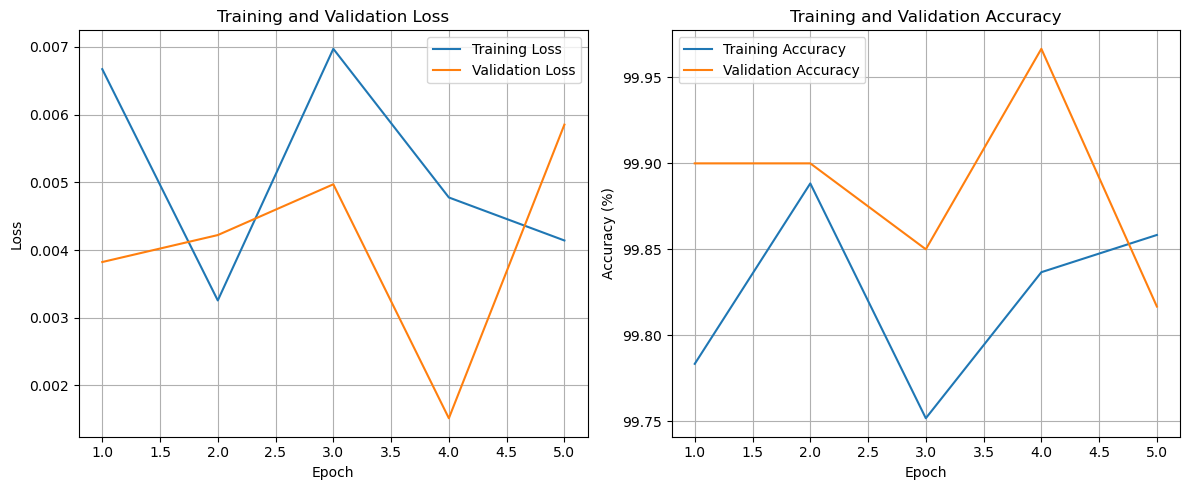

In [44]:
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accs, label='Training Accuracy')
plt.plot(epochs_range, val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()